# Population genetic simulaion with phenotypic noise

In [1]:
import hanoi
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
%matplotlib inline

# How to represent data

## Basic parameters

Population size $N$

In [2]:
N = 18
print(N)

18


Number of traits $n$

In [3]:
n = 2

Number of loci L

In [4]:
L = 5

## Mutation effect

### Phenotypic mean

Effect of allele `1` at $L$  loci on **mean (phenotypic expectation)** of $n$ traits compared to allele `0` is represented in $M_m$, a 2D array ($n \times L$) 

$M_m = 
\begin{pmatrix}
\mu_{1(0,0)} & \mu_{1(0,1)} & ... & \mu_{1,(0,L-1)}\\
\mu_{1(1,0)} & \mu_{1(1,1)} & ... & \mu_{1,(1,L-1)}\\
\vdots & \vdots & \vdots & \vdots\\
\vdots & \vdots & \mu_{1(j,l)} & \vdots\\
\vdots & \vdots & \vdots & \vdots\\
\mu_{1(n-1,0)} & \mu_{1(n-1,1)} & ... & \mu_{1,(n-1,L-1)}\\
\end{pmatrix}
$

In [5]:
M_m = np.array([[1, 0, 0, 0, 0], 
                [0, 1, 0, 0, 0]],
               dtype = np.float64
               )
print(M_m)

[[1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0.]]


In this scenario, allele `1` of locus 0 increases phenotype of trait 1 by 1.0, and allele `1` of locus 1 increases the phenotype of trait 2 by 1.0

### Phenotypic variance

Effect of allele `1` at $L$  loci on **variance (phenotypic noise)** of $n$ traits compared to allele `0` is represented in $M_v$, a 2D array ($n \times L$) 

$M_v = 
\begin{pmatrix}
\sigma^2_{1(0,0)} & \sigma^2_{1(0,1)} & ... & \sigma^2_{1,(0,L-1)}\\
\sigma^2_{1(1,0)} & \sigma^2_{1(1,1)} & ... & \sigma^2_{1,(1,L-1)}\\
\vdots & \vdots & \vdots & \vdots\\
\vdots & \vdots & \sigma^2_{1(j,l)} & \vdots\\
\vdots & \vdots & \vdots & \vdots\\
\sigma^2_{1(n-1,0)} & \sigma^2_{1(n-1,1)} & ... & \sigma^2_{1,(n-1,L-1)}\\
\end{pmatrix}
$

In [6]:
M_v = np.array([[0, 0, 0.01, 0, 0], 
                [0, 0, 0, 0.01, 0]],
               dtype = np.float64
               )
print(M_v)

[[0.   0.   0.01 0.   0.  ]
 [0.   0.   0.   0.01 0.  ]]


In this scenario, allele `1` of locus 2 increases the variance of trait 1 by 0.01 (so increase SD by 0.1), and allele `1` of locus 3 increases the variance of trait 2 by 0.01.

### Phenotypic covariance

Effect of allele `1` at $L$  loci on **covariance ((in)dependence of development among traits)** of $\binom{n}{2}$ traits compared to allele `0` is represented in $M_v$, a 2D array ($\binom{n}{2} \times L$) 

$M_c = 
\begin{pmatrix}
cov_{1((0,1), 0)} & cov_{1((0,1), 1)} & ... & cov_{1((0,1), L-1)}\\
cov_{1((0,2), 0)} & cov_{1((0,2), 1)} & ... & cov_{1((0,2), L-1)}\\
\vdots & \vdots & \vdots & \vdots\\
\vdots & \vdots & cov_{1((j,k),l)} & \vdots\\
\vdots & \vdots & \vdots & \vdots\\
cov_{1((n-2,n-1), 0)} & cov_{1((n-2,n-1), 1)} & ... & cov_{1((n-2,n-1), L-1)}
\end{pmatrix}
$

In [7]:
M_c = np.array([[0, 0, 0, 0, -0.009]],
               dtype = np.float64
               )
print(M_c)

[[ 0.     0.     0.     0.    -0.009]]


In this scenario, allele `1` of locus 4 reduces the covariance between trait 1 and trait 2 by 0.0009.

Note when $n = 1$, $M_c$ is empty, with 0 rows

Note for now I am assuming that each locus has one effect.
In other words, I assume **no pleiotropy between traits**, and **no expectation-noise dependence**.

In [8]:
np.concatenate((M_m, M_v, M_c), axis = 0)

array([[ 1.   ,  0.   ,  0.   ,  0.   ,  0.   ],
       [ 0.   ,  1.   ,  0.   ,  0.   ,  0.   ],
       [ 0.   ,  0.   ,  0.01 ,  0.   ,  0.   ],
       [ 0.   ,  0.   ,  0.   ,  0.01 ,  0.   ],
       [ 0.   ,  0.   ,  0.   ,  0.   , -0.009]])

### hanoi.MutEffect

In `hanoi`, mutation effects of loci on traits are represented by objects of `MutEffect` type.

In [9]:
hanoi.MutEffect?

Init signature:
hanoi.MutEffect(
    mean: numpy.ndarray,
    var: numpy.ndarray,
    cov: numpy.ndarray,
)
Docstring:     
A class to represent mutational effects on mean, variance, and covariance of traits.

Attributes
----------
mean : Mean effects. 
    Should be a 2D np.array of shape (n, L). 
    mean[i, j] holds the effect of allele 1 at locus j on trait i.
var : Variance effects.
    Should be a 2D np.array of shape (n, L).
    var[i, j] holds the effect of allele 1 at locus j on trait i.
cov : Covariance effects.
    Should be a 2D np.array of shape (choose(n, 2), L).
    cov[i, j] holds the effect of allele 1 at locus j on the i-th trait pair.
n : Number of traits
L : Number of loci


Methods
-------
show() : Prints information of the MutEffect object.
File:           ~/SeaDrive/My Libraries/mylib/work/projects/python/packages/hanoi/hanoi/hanoi.py
Type:           type
Subclasses:     

In [10]:
M = hanoi.MutEffect(mean = M_m, var = M_v, cov = M_c)
M.show()

Number of traits n:
2
Number of trait pairs:
1
Number of loci L:
5
Mutation effect of mean:
[[1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0.]]
Mutation effect of variance:
[[0.   0.   0.01 0.   0.  ]
 [0.   0.   0.   0.01 0.  ]]
Mutation effect of covariance:
[[ 0.     0.     0.     0.    -0.009]]


## Genotype

The genotypes of $N$ diploid individuals at $L$ loci are represented as a matrix of $(L, N)$ (like VCF).

$G = 
\begin{pmatrix}
g_{0,0} & g_{0, 1} & ... & g_{0, N-1}\\
g_{1,0} & g_{1, 1} & ... & g_{1, N-1}\\
\vdots & \vdots & \vdots & \vdots\\
\vdots & \vdots & g_{l,i} & \vdots\\
\vdots & \vdots & \vdots & \vdots\\
g_{L-1,0} & g_{L-1, 1} & ... & g_{L-1, N-1}\\
\end{pmatrix}
$

$g_{l,i} \in \{0, 1, 2\}$

In [11]:
G = np.zeros((L, N), dtype = np.float64)
G

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0.]])

In [12]:
for i in range(L):
    G[i, 2*i:2*(i+1)]  = 0
    G[i, 2*(i+1):2*(i+2)] = 1
    G[i, 2*(i+2):2*(i+3)] = 2
G[:, 14:16] = 1
G[:, 16:18] = 2
G

array([[0., 0., 1., 1., 2., 2., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1.,
        2., 2.],
       [0., 0., 0., 0., 1., 1., 2., 2., 0., 0., 0., 0., 0., 0., 1., 1.,
        2., 2.],
       [0., 0., 0., 0., 0., 0., 1., 1., 2., 2., 0., 0., 0., 0., 1., 1.,
        2., 2.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 2., 2., 0., 0., 1., 1.,
        2., 2.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 2., 2., 1., 1.,
        2., 2.]])

In [13]:
G.shape

(5, 18)

# How to simulate one generation

## Breeding value (Genetic value)

Based on the **mutation effects** and **genotype**, multivariate **breeding value** is computed for each of the $N$ individuals.
Just as mutation effects, the breeding value in my model consists of three components: mean of $n$ traits, variance (size of phenotypic noise) of $n$ traits), and covariance (dependence) of between $\binom{n}{2}$ pairs of $n$ traits.

### Breeding value of mean (phenotypic expectation)

**Breeding values of mean** of $n$ traits of $N$ individuals are represented by $A_m$, a matrix of $(n, N)$.
Breeding value of each individual is simply the sum of effects of allele 1 at all loci.

$
A_m = 
\begin{pmatrix}
a_{m(0,0)} & a_{m(0,1)} & ... & a_{m(0,N-1)}\\
a_{m(1,0)} & a_{m(1,1)} & ... & a_{m(1,N-1)}\\
\vdots & \vdots & \vdots & \vdots\\
\vdots & \vdots & a_{m(j,i)} & \vdots\\
\vdots & \vdots & \vdots & \vdots\\
a_{m(n,0)} & a_{m(n,1)} & ... & a_{m(n,N-1)}\\
\end{pmatrix} = \dfrac{1}{2} M_m G
$

$a_{m(j,i)} = \sum_\limits{l=0}^{L-1}{\frac{1}{2} \mu_{1(j,l)} g_{l,i} }$

### Breeding value of variance (phenotypic noise)

Similarly, **breeding values of variance** of $n$ traits of $N$ individuals are represented by $A_v$.

$
A_v = 
\begin{pmatrix}
a_{v(0,0)} & a_{v(0,1)} & ... & a_{v(0,N-1)}\\
a_{v(1,0)} & a_{v(1,1)} & ... & a_{v(1,N-1)}\\
\vdots & \vdots & \vdots & \vdots\\
\vdots & \vdots & a_{v(j,i)} & \vdots\\
\vdots & \vdots & \vdots & \vdots\\
a_{v(n-1,0)} & a_{v(n-1,1)} & ... & a_{v(n-1,N-1)}\\
\end{pmatrix} = \dfrac{1}{2} M_v G
$

$a_{v(j,i)} = \sum_\limits{l=0}^{L-1}{\frac{1}{2} \sigma^2_{1(j,l)} g_{l,i} }$

### Breeding value of covariance (developmental dependence between traits)

And **breeding values of covariance** of $\binom{n}{2}$ pairs of traits of $N$ individuals are represented by $A_c$

$
A_c = 
\begin{pmatrix}
a_{c((0,1),0)} & a_{c((0,1),1)} & ... & a_{v((0,1),N-1)}\\
a_{c((0,2),0)} & a_{c((0,2),1)} & ... & a_{v((0,2),N-1)}\\
\vdots & \vdots & \vdots & \vdots\\
\vdots & \vdots & a_{c((j,k),i)} & \vdots\\
\vdots & \vdots & \vdots & \vdots\\
a_{c((n-2,n-1),0)} & a_{c((n-2,n-2),1)} & ... & a_{c(n-2,n-1),N-1)}\\
\end{pmatrix} = \dfrac{1}{2} M_c G
$

$j \ne k$

$a_{c((j,k),i)} = \sum_\limits{l=0}^{L-1}{\frac{1}{2} cov_{1((j,k),l)} g_{l,i} }$

### Implementation of breeding value in `hanoi`

This structure of breeding value can be represented in an object of `hanoi.BreedVal` type.

In [14]:
hanoi.BreedVal??

Init signature: hanoi.BreedVal(mean: numpy.ndarray, var: numpy.ndarray, cov: numpy.ndarray)
Source:        
class BreedVal:
    """
    A class to represent breeding value of all individuals in a population

    Attributes
    ----------
    mean : Breeding value of mean $A_m$.
           Should be a 2D np.ndarray of shape (n, N).
           mean[i, j] holds the breeding value of mean of trait i for individual j.
    var : Breeding value of variance $A_v$
           Should be a 2D np.ndarray of shape (n, N).
           var[i, j] holds the breeding value of variance of trait i for individual j.
    cov : Breeding value of covariance $A_c$.
           Should be a 2D np.ndarray of shape (choose(n, 2), N).
           cov[i, j] holds the breeding value of covariance of the trait pair i for individual j.
    n : Number of traits
    N : Number of individuals


    Methods
    -------
    show() : Prints information of the BreedVal object.

    """
    def __init__(self, mean: np.ndarray, var

`hanoi.BreedVal` can be computed from the genotype (`np.ndarray`)and mutation effects (`hanoi.MutEffect`) using `hanoi.comp_breed_val()` function.

In [15]:
hanoi.comp_breed_val??

Signature:
hanoi.comp_breed_val(
    mut_effect: hanoi.hanoi.MutEffect,
    genotype: numpy.ndarray,
)
Source:   
def comp_breed_val(mut_effect: MutEffect, genotype: np.ndarray):
    """
    Computes breeding value from mutation effect and genotype.

    Args:
        mut_effect : hanoi.MutEffect object representing mutation effect.
        genotype :   2D np.ndarray representing a genotype table.

    Returns: hanoi.BreedVal object representing breeding value
    """
    A_m = 1/2 * mut_effect.mean @ genotype
    A_v = 1/2 * mut_effect.var @ genotype
    A_c = 1/2 * mut_effect.cov @ genotype
    return BreedVal(mean = A_m, var = A_v, cov = A_c)
File:      ~/SeaDrive/My Libraries/mylib/work/projects/python/packages/hanoi/hanoi/hanoi.py
Type:      function

In [16]:
A = hanoi.comp_breed_val(mut_effect = M, genotype = G)

In [17]:
A.show()

Number of traits:
 2
Number of trait pairs:
 1
Number of individuals:
 18
Breeding value of mean:
 [[0.  0.  0.5 0.5 1.  1.  0.  0.  0.  0.  0.  0.  0.  0.  0.5 0.5 1.  1. ]
 [0.  0.  0.  0.  0.5 0.5 1.  1.  0.  0.  0.  0.  0.  0.  0.5 0.5 1.  1. ]]
Breeding value of variance:
 [[0.    0.    0.    0.    0.    0.    0.005 0.005 0.01  0.01  0.    0.
  0.    0.    0.005 0.005 0.01  0.01 ]
 [0.    0.    0.    0.    0.    0.    0.    0.    0.005 0.005 0.01  0.01
  0.    0.    0.005 0.005 0.01  0.01 ]]
Breeding value of covariance:
 [[ 0.      0.      0.      0.      0.      0.      0.      0.      0.
   0.     -0.0045 -0.0045 -0.009  -0.009  -0.0045 -0.0045 -0.009  -0.009 ]]
Breeding value of variance-covariance:
 [[[ 0.      0.    ]
  [ 0.      0.    ]]

 [[ 0.      0.    ]
  [ 0.      0.    ]]

 [[ 0.      0.    ]
  [ 0.      0.    ]]

 [[ 0.      0.    ]
  [ 0.      0.    ]]

 [[ 0.      0.    ]
  [ 0.      0.    ]]

 [[ 0.      0.    ]
  [ 0.      0.    ]]

 [[ 0.005   0.    ]
  [ 0.   

## Phenotype

The phenotype $z_i$ of individual $i$ is sampled from a **multivariate normal distribution**, whose parameter specific to individual $i$ is based on the breeding value. 

$z_{i} = 
\begin{pmatrix}
z_{i(0)}\\
z_{i(1)}\\
\vdots\\
z_{i(n-1)}\\
\end{pmatrix}
\sim \mathcal{N}(z_\mathrm{ref} + A_{m(i)}, c_\mathrm{ref} + A_{vc(i)})$

where

$z_\mathrm{ref} = 
\begin{pmatrix}
z_{\mathrm{ref}(0)}\\
z_{\mathrm{ref}(1)}\\
\vdots\\
z_{\mathrm{ref}(n-1)}\\
\end{pmatrix}
$

$c_\mathrm{ref}=
\begin{pmatrix}
\sigma^2_\mathrm{ref(0)} & cov_\mathrm{ref(0,1)} & ... & cov_\mathrm{ref(0,n-1)}\\
cov_\mathrm{ref(1,0)} & \sigma^2_\mathrm{ref(1)} &  ... & cov_\mathrm{ref(1,n-1)}\\
\vdots & \vdots & & \vdots \\
cov_\mathrm{ref(n-1,0)} &   cov_\mathrm{ref(n-1,1)} &... & \sigma^2_\mathrm{ref(n-1)} \\
\end{pmatrix}
$

and

$A_{m(i)} = 
\begin{pmatrix}
a_{m(i,0)}\\
a_{m(i,1)}\\
\vdots\\
a_{m(i,n-1)}
\end{pmatrix}$

$A_{vc(i)} = 
\begin{pmatrix}
a_{v(0,i)} & a_{c((0,1),i)} & ... & a_{c((0,n-1),i)}\\
a_{c((1,0),i)} & a_{v(1,i)} & ... & a_{c((1,n-1),i)}\\
\vdots & \vdots & &  \vdots\\
a_{c((n-2, 0),i)} & a_{c((n-2, n-1),i)} & ... & a_{v(n-1, i)}
\end{pmatrix}$

For the demonstration, I assume

$z_\mathrm{ref} =
\begin{pmatrix}
0\\
0
\end{pmatrix}
$

$c_\mathrm{ref} = 
\begin{pmatrix}
0.01 & 0\\
0 & 0.01
\end{pmatrix}
$

In [18]:
z_ref = np.array([0,0], dtype = np.float64)
c_ref = np.array([[0.01,0.00],
                  [0.00,0.01]], dtype = np.float64)

In [19]:
print(z_ref)

[0. 0.]


In [20]:
print(c_ref)

[[0.01 0.  ]
 [0.   0.01]]


Simulation of phenotypes is implemented in `hanoi.sim_pheno()` function.

In [21]:
hanoi.sim_pheno?

Signature: hanoi.sim_pheno(breed_val: hanoi.hanoi.BreedVal, mean_0, varcov_0)
Docstring:
Simulates phenotype.

Arguments:
    breed_val : hanoi.BreedVal object representing breeding value.
    mean_0 :    2D np.ndarray of (n, N) representing expectation of n traits for a genotype of 0000...
    varcov_0 :  2D np.ndarray of (n, n) representing baseline variance-covariance matrix for a genotype of 0000....

Returns: 2D np.ndarray of (N, n) representing phenotype.
         [i, j] represents the phenotype of individual i for trait j.
File:      ~/SeaDrive/My Libraries/mylib/work/projects/python/packages/hanoi/hanoi/simulate.py
Type:      function

In [22]:
z = hanoi.sim_pheno(breed_val = A, mean_0 = z_ref, varcov_0 = c_ref)

In [23]:
z

array([[ 0.04354445, -0.04035041],
       [ 0.03690817, -0.1616049 ],
       [ 0.55214637,  0.07227863],
       [ 0.33449404, -0.01530801],
       [ 1.13437384,  0.49099751],
       [ 1.2118429 ,  0.6574226 ],
       [ 0.17471269,  0.96849357],
       [ 0.14736663,  0.89711848],
       [ 0.06635022,  0.11105608],
       [ 0.1256321 ,  0.1063908 ],
       [ 0.05716785,  0.30340332],
       [-0.05318414,  0.12539295],
       [ 0.13440668, -0.11924154],
       [ 0.07448288, -0.03232376],
       [ 0.57170199,  0.45393834],
       [ 0.46140216,  0.5795883 ],
       [ 0.71450042,  1.23661827],
       [ 1.03337124,  1.0326823 ]])

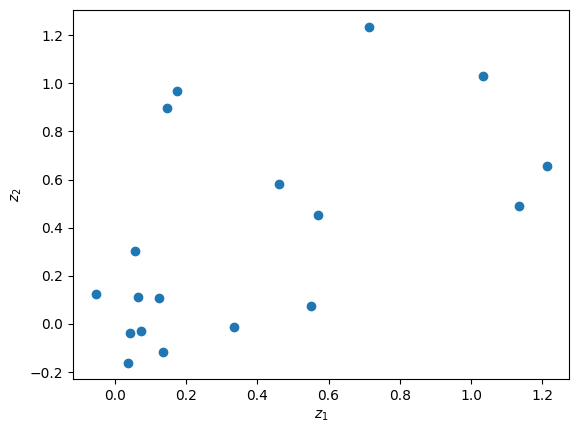

In [24]:
plt.scatter(z[:,0], z[:,1])
plt.xlabel("$z_1$")
plt.ylabel("$z_2$")
plt.show()

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from scipy.stats import chi2

def plot_bivariate_normal_contour(mean, cov, percentile=0.95, ax=None, **ellipse_kwargs):
    """
    Plots the contour of a bivariate normal distribution for a given percentile.

    Parameters:
        mean : array-like of shape (2,)
            Mean of the distribution.
        cov : array-like of shape (2,2)
            Covariance matrix.
        percentile : float
            Probability mass to enclose (default 0.95).
        ax : matplotlib Axes, optional
            Axes to draw on. If None, creates a new figure.
        ellipse_kwargs : additional kwargs for matplotlib.patches.Ellipse
            e.g., edgecolor, facecolor, linewidth, label
    """
    mean = np.asarray(mean)
    cov = np.asarray(cov)

    # Eigen decomposition
    eigvals, eigvecs = np.linalg.eigh(cov)
    order = eigvals.argsort()[::-1]  # descending
    eigvals, eigvecs = eigvals[order], eigvecs[:, order]

    # Rotation angle of ellipse
    angle = np.degrees(np.arctan2(eigvecs[1,0], eigvecs[0,0]))

    # Chi-square scaling for desired percentile
    s = chi2.ppf(percentile, df=2)

    # Width and height
    width, height = 2 * np.sqrt(eigvals * s)

    # Create plot if needed
    if ax is None:
        fig, ax = plt.subplots()

    # Draw ellipse
    ellipse = Ellipse(mean, width=width, height=height, angle=angle, **ellipse_kwargs)
    ax.add_patch(ellipse)
    
    return ax

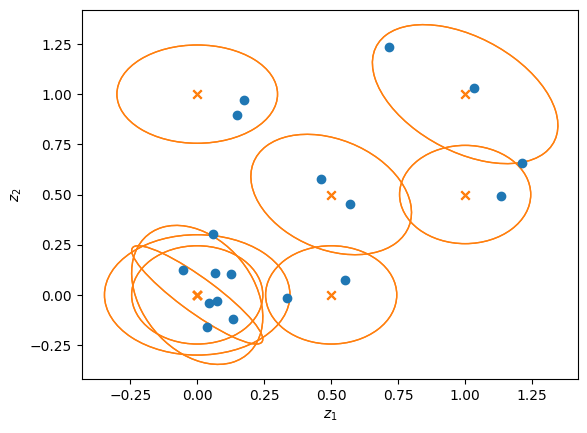

In [27]:
fig, ax = plt.subplots()
#ax.scatter(A.mean.T[:,0], A.mean.T[:,1])
ax.scatter(A.mean.T[:,0], A.mean.T[:,1], color = 'tab:orange', marker = 'x')

for i in range(len(A.mean.T)):
    plot_bivariate_normal_contour(mean = z_ref + A.mean[:,i], cov = c_ref + A.varcov[i], percentile=0.95, ax=ax, facecolor = 'none', edgecolor = "tab:orange")
    
ax.scatter(z[:,0], z[:,1], color = 'tab:blue')

plt.xlabel("$z_1$")
plt.ylabel("$z_2$")
plt.savefig("2025_09_01_out_1.pdf")
plt.show()

## Fitness functions

I implemented four kinds of fitness functions

### Neutral

In [27]:
hanoi.fit_neutral(z)

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1.])

### Gaussian fitness function

In [28]:
hanoi.fit_gaus?

Signature: hanoi.fit_gaus(sigma, z_opt, z)
Docstring:
sigma: A scalar specifying SD around the peak
z_opt: (n,) array specifying the coordinate of the peak in the n dimensional phenotypic space
z:      (N, n) array representing n-dimensional phenotypes of N individuals.
Returns: (N,) array representing fitness of N individuals
File:      ~/Dropbox/work/projects/python/packages/hanoi/hanoi/fitness.py
Type:      function

For one trait

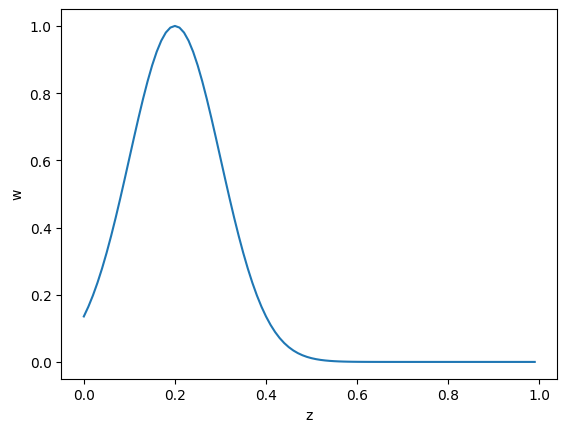

In [28]:
z_1D = np.arange(100, dtype = np.float64)/100
w1 = hanoi.fit_gaus(z_opt = np.array([0.2], dtype = np.float64), 
                    sigma = 0.1,
                    z = z_1D
                   )
plt.plot(z_1D, w1)
plt.xlabel("z")
plt.ylabel("w")
plt.show()

For 2 traits

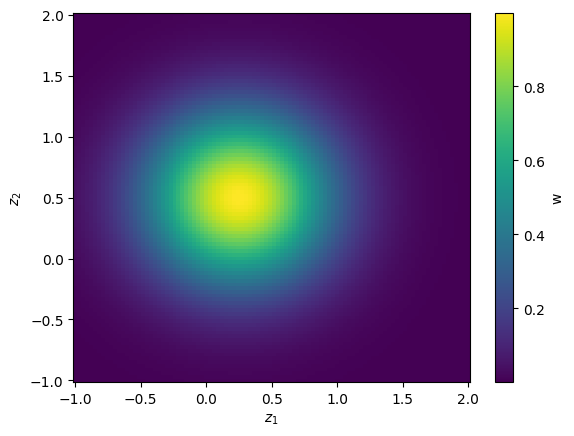

In [29]:
# Make meshgrid
X, Y = np.meshgrid(np.linspace(-1,2,100), np.linspace(-1,2,100))

# Flatten to feed into fit_gaus
z2 = np.column_stack([X.ravel(), Y.ravel()])

# Evaluate w2
w2_g = hanoi.fit_gaus(z_opt=np.array([0.25, 0.5], dtype=np.float64),
                    sigma=0.5,
                    z=z2)

# Reshape to grid for pcolormesh
w2_g_grid = w2_g.reshape(100, 100)

fig, ax = plt.subplots()

# Draw tiled background
pcm = ax.pcolormesh(X, Y, w2_g_grid, cmap='viridis', shading='auto')
plt.colorbar(pcm, ax=ax, label='w')

ax.set_xlabel('$z_1$')
ax.set_ylabel('$z_2$')
plt.show()


We can apply this 2D Gaussian fitness function to the 2D traits

In [30]:
w = hanoi.fit_gaus(z_opt = np.array([0.25,0.5], dtype = np.float64),
                 sigma = 0.5,
                 z = z
                )

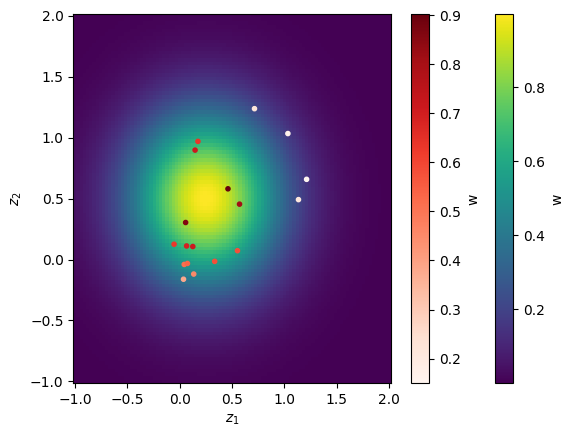

In [31]:
fig, ax = plt.subplots()

# Draw tiled background
pcm = ax.pcolormesh(X, Y, w2_g_grid, cmap='viridis', shading='auto')
plt.colorbar(pcm, ax=ax, label='w')

plt.scatter(z[:,0], z[:,1], c=w,  cmap='Reds', marker = '.')

plt.colorbar(label='w')
ax.set_xlabel('$z_1$')
ax.set_ylabel('$z_2$')
plt.show()

### Multimodal fitness function

For one trait

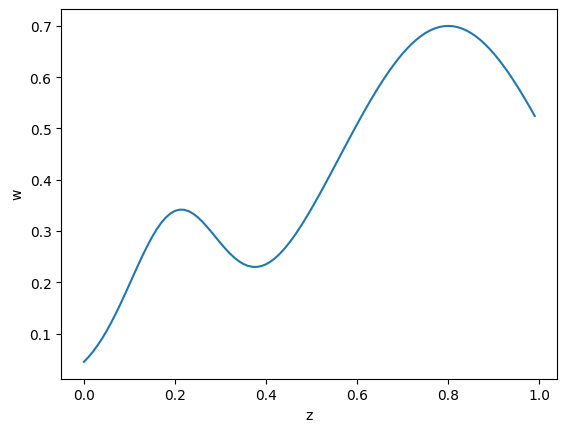

In [32]:
w1_m = hanoi.fit_multimodal(sigma = np.array([0.1, 0.25]), 
                            p = np.array([0.3, 0.7]), 
                            z_opt = np.array([[0.2],[0.8]]), 
                            z = z_1D
                           )
plt.plot(z_1D, w1_m)
plt.xlabel("z")
plt.ylabel("w")
plt.show()

For 2D trait

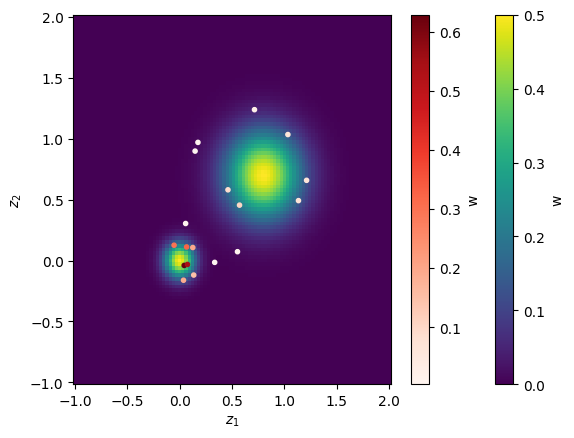

In [33]:
w2_m = hanoi.fit_multimodal(sigma = np.array([0.1, 0.25]), 
                            p = np.array([0.5, 0.5]), 
                            z_opt = np.array([[0,0],[0.8,0.7]]), 
                            z = z2
                           )
w = hanoi.fit_multimodal(sigma = np.array([0.1, 0.25]), 
                            p = np.array([0.75, 0.25]), 
                            z_opt = np.array([[0,0],[0.8,0.7]]), 
                            z = z
                           )


# Reshape to grid for pcolormesh
w2_m_grid = w2_m.reshape(100, 100)

fig, ax = plt.subplots()

# Draw tiled background
pcm = ax.pcolormesh(X, Y, w2_m_grid, cmap='viridis', shading='auto')
plt.colorbar(pcm, ax=ax, label='w')

plt.scatter(z[:,0], z[:,1], c = w, cmap = 'Reds', marker = '.')
plt.colorbar(label="w")
plt.xlabel("$z_1$")
plt.ylabel("$z_2$")
plt.show()

### Step fitness function

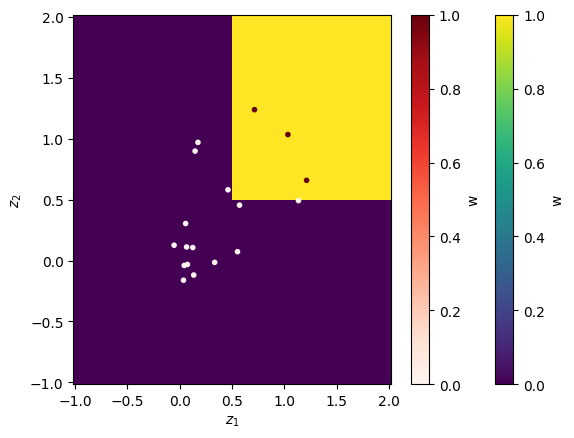

In [34]:
w2_s = hanoi.fit_step(z = z2, boxes = np.array([[[0.5, 0.5], [np.inf, np.inf]]]))
w = hanoi.fit_step(z = z, boxes = np.array([[[0.5, 0.5], [np.inf, np.inf]]]))

# Reshape to grid for pcolormesh
w2_s_grid = w2_s.reshape(100, 100)

fig, ax = plt.subplots()

# Draw tiled background
pcm = ax.pcolormesh(X, Y, w2_s_grid, cmap='viridis', shading='auto')
plt.colorbar(pcm, ax=ax, label='w')

plt.scatter(z[:,0], z[:,1], c = w, cmap = 'Reds', marker = '.')
plt.colorbar(label="w")
plt.xlabel("$z_1$")
plt.ylabel("$z_2$")
plt.show()



## Mutation

Germline mutation is simulated.

I assume that mutation occurs after development of phenotype (or independent of phenotype) and before meiosis.

When mutation rate is $u$ \[per locus per generation\], the probability for a diploid genotype $i$ to change into $j$ is described by $p_u(i,j)$ of a transition matrix $p_u$

$p_u =
\begin{pmatrix}
(1 - u)^2 & 2 u (1 - u) & u^2\\
u (1 - u) & (1 - u)^2 + u^2 & u  (1 - u)\\
u^2 & 2 u (1 - u) & (1 - u)^2
\end{pmatrix}$

In `hanoi`, this is implemented in `hanoi.sim_mutation()` function.

In [35]:
hanoi.sim_mutation?

Signature: hanoi.sim_mutation(genotype, mut_rate)
Docstring:
Simulates mutation.

Arguments :
    genotype : 2D np.ndarray representing genotye table before mutation.
    mut_rate : float representing mutation rate per locus per generation.

Returns: 2D np.ndarray representing genotype table after mutation.
File:      ~/SeaDrive/My Libraries/mylib/work/projects/python/packages/hanoi/hanoi/simulate.py
Type:      function

In [36]:
G

array([[0., 0., 1., 1., 2., 2., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1.,
        2., 2.],
       [0., 0., 0., 0., 1., 1., 2., 2., 0., 0., 0., 0., 0., 0., 1., 1.,
        2., 2.],
       [0., 0., 0., 0., 0., 0., 1., 1., 2., 2., 0., 0., 0., 0., 1., 1.,
        2., 2.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 2., 2., 0., 0., 1., 1.,
        2., 2.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 2., 2., 1., 1.,
        2., 2.]])

In [37]:
G_mut = hanoi.sim_mutation(genotype = G, mut_rate = 0.1)
G_mut

array([[0., 0., 0., 1., 2., 1., 0., 0., 0., 1., 0., 0., 0., 0., 1., 1.,
        2., 1.],
       [0., 0., 0., 0., 1., 1., 2., 2., 2., 0., 0., 0., 1., 0., 1., 0.,
        2., 1.],
       [0., 0., 0., 0., 0., 0., 1., 1., 1., 2., 0., 1., 0., 0., 0., 1.,
        2., 2.],
       [0., 1., 0., 0., 0., 1., 0., 0., 1., 1., 2., 2., 0., 0., 1., 2.,
        2., 2.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 2., 2., 2., 1., 0.,
        1., 1.]])

In [38]:
G == G_mut

array([[ True,  True, False,  True,  True, False,  True,  True,  True,
        False,  True,  True,  True,  True,  True,  True,  True, False],
       [ True,  True,  True,  True,  True,  True,  True,  True, False,
         True,  True,  True, False,  True,  True, False,  True, False],
       [ True,  True,  True,  True,  True,  True,  True,  True, False,
         True,  True, False,  True,  True, False,  True,  True,  True],
       [ True, False,  True,  True,  True, False,  True,  True,  True,
         True,  True,  True,  True,  True,  True, False,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True,  True,
         True,  True, False,  True,  True,  True, False, False, False]])

## Reproduction

$N$ individuals of offspring have $2N$ haploid genomes.

For one haploid genome of offspring, the probability $p_i$ that an individual $i$ is the parent is its fitness relative to the total fitness of all individuals

$p_i = \dfrac{W_i}{N\overline{W}} = \dfrac{W_i}{\sum_\limits{j=0}^{L-1}{W_j}}$

The joint distribution of the number of offspring $N_i'$ of $N$ individuals ($i \in \{0, 1, ..., N-1\}$) follows a **multinomial distribution**.

$(N_0', N_1', ..., N_{N-1}') \sim \mathrm{multinom}(p_0, p_1, ..., p_{N-1})$

where $\sum_\limits{i=0}^{N-1}{N_i'} = 2N$ and $\sum_\limits{i=0}^{N-1}{p_i} = 1$

Each of $N$ individuals of offspring will have two parents randomly picked from the multinomial variable.

This sampling representing reproduction according to fitness is implemented in `hanoi.sim_reproduction()` function.

In [39]:
hanoi.sim_reproduction??

Signature: hanoi.sim_reproduction(popsize, genotype, fitness)
Source:   
def sim_reproduction(popsize, genotype, fitness):
    """
    Simulates reproduction.

    Arguments:
        popsize :  int N representing population size
        genotype : 2D np.ndarray of (L, N) representing genotype of parents.
        fitness :  1D np.ndarray of N representing fitness of parents.

    Returns: A tuple (genotype_next, n_offspring)
        genotype_next : 2D np.ndarray of (L, N) representing genotype of the offspring
        n_offspring :  Number of offspring.
                        Should be a 1D np.ndarray of length N and the sum should be 2N.
                        n_offspring[i] holds the number of offspring of parent individual i.
    """
    # number of offspring per genotype of each genotype
    n_loci = genotype.shape[0]
    if fitness.sum() == 0:
        genotype_next = np.full((n_loci, popsize), np.nan)
        n_offspring = np.zeros(popsize, dtype = int)
        #raise RuntimeErro

`hanoi.sim_reproduction()` returns a tuple of two:

1. genotype matrix of the offspring
2. number of offspring of each individual

### e.g. Gaussian fitness function

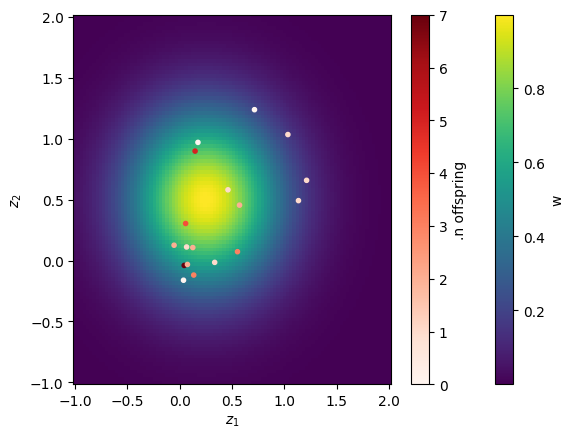

In [40]:
w = hanoi.fit_gaus(z_opt = np.array([0.25,0.5], dtype = np.float64),
               sigma = 0.5,
               z = z
              )
G_next, n_offspring = hanoi.sim_reproduction(popsize = N, genotype = G, fitness = w)

fig, ax = plt.subplots()

# Draw tiled background
pcm = ax.pcolormesh(X, Y, w2_g_grid, cmap='viridis', shading='auto')
plt.colorbar(pcm, ax=ax, label='w')

plt.scatter(z[:,0], z[:,1], c=n_offspring,  cmap='Reds', marker = '.')

plt.colorbar(label='.n offspring')
ax.set_xlabel('$z_1$')
ax.set_ylabel('$z_2$')
plt.show()

In [41]:
G_next

array([[0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0],
       [1, 0, 2, 1, 1, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0],
       [0, 1, 2, 0, 1, 0, 0, 0, 0, 2, 0, 1, 0, 0, 1, 0, 0, 0],
       [1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0],
       [0, 1, 0, 1, 1, 0, 0, 1, 1, 2, 0, 0, 1, 0, 0, 0, 1, 1]])

### e.g. Multinomial fitness function

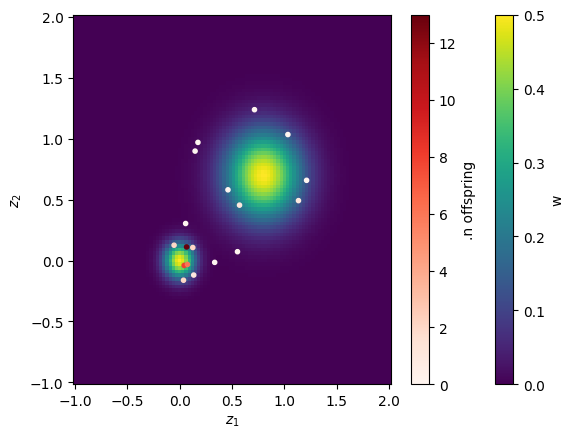

In [42]:
w = hanoi.fit_multimodal(sigma = np.array([0.1, 0.25]), 
                            p = np.array([0.75, 0.25]), 
                            z_opt = np.array([[0,0],[0.8,0.7]]), 
                            z = z
                           )
G_next, n_offspring = hanoi.sim_reproduction(popsize = N, genotype = G, fitness = w)

fig, ax = plt.subplots()

# Draw tiled background
pcm = ax.pcolormesh(X, Y, w2_m_grid, cmap='viridis', shading='auto')
plt.colorbar(pcm, ax=ax, label='w')

plt.scatter(z[:,0], z[:,1], c=n_offspring,  cmap='Reds', marker = '.')

plt.colorbar(label='.n offspring')
ax.set_xlabel('$z_1$')
ax.set_ylabel('$z_2$')
plt.show()

### e.g. Step fitness function

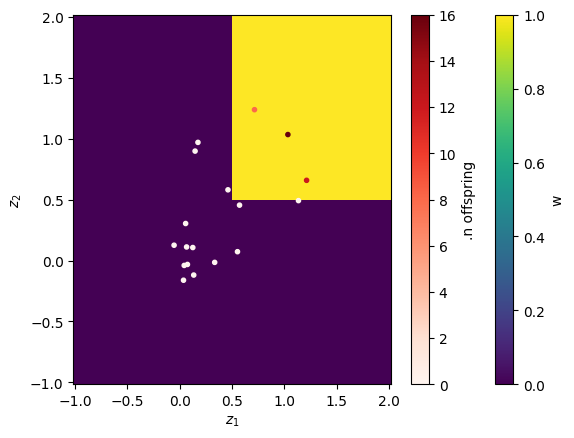

In [43]:
w = hanoi.fit_step(z = z, boxes = np.array([[[0.5, 0.5], [np.inf, np.inf]]]))
G_next, n_offspring = hanoi.sim_reproduction(popsize = N, genotype = G, fitness = w)

fig, ax = plt.subplots()

# Draw tiled background
pcm = ax.pcolormesh(X, Y, w2_s_grid, cmap='viridis', shading='auto')
plt.colorbar(pcm, ax=ax, label='w')

plt.scatter(z[:,0], z[:,1], c=n_offspring,  cmap='Reds', marker = '.')

plt.colorbar(label='.n offspring')
ax.set_xlabel('$z_1$')
ax.set_ylabel('$z_2$')
plt.show()

## `hanoi.Generation` class

The info about mutation effect, genotypes, breeding values, fitness, number of offspring, genotype of the next generation can be put in one object of `hanoi.Generation` class.

In [44]:
hanoi.Generation?

Init signature:
hanoi.Generation(
    genotype: numpy.ndarray,
    genotype_next: numpy.ndarray,
    breed_val: hanoi.hanoi.BreedVal,
    phenotype: numpy.ndarray,
    fitness: numpy.ndarray,
    n_offspring: numpy.ndarray,
)
Docstring:     
A class to represent one generation of a population

Attributes
----------
genotype :      Genotype matrix of parents.
                Should be a 2D np.ndarray of shape (L, N).
                genotype[i, j] holds the genotype of individual j at locus i.
breed_val :     Breeding value of parents.
                Should be of type hanoi.BreedVal.
phenotype :     Phenotype matrix of parents.
                Should be a 2D np.ndarray of shape (N, n).
                phenotype[i, j] holds the phenotype of individual i for trait j.
fitness :       Fitness matrix of parents.
                Should be a 1D np.ndarray of length N.
                fitness[i] holds the fitness of individual i.
n_offspring :   Number of offspring.
                Should be a

## `hanoi.sim_generation()`

Simulation of one cycle of generation is implemented in `hanoi.sim_generation()` function.

In [45]:
hanoi.sim_generation?

Signature:
hanoi.sim_generation(
    mut_effect,
    genotype,
    mut_rate,
    fit_func,
    mean_0,
    varcov_0,
    **kwargs,
)
Docstring:
Simulates one generation.

Arguments:
    mut_effect : hanoi.MutEffect object representing mutation effect.
    genotype :   2D np.ndarray of (L, N) representing genotype.
    mut_rate :   float representing mutation rate per locus per generation.
    fit_func :   Fitness function.
                 "fit_neutral", "fit_gaus", "fit_multimodal", "fit_step"
    mean_0 :     2D np.ndarray of (n, N) representing expectation of n traits for a genotype of 0000...
    varcov_0 :   2D np.ndarray of (n, n) representing baseline variance-covariance matrix for a genotype of 0000....
    **kwargs :   Extra arguments passed to fitness function. For more details, see help of fit_neutral, fit_gaus, fit_multimodal, fit_step.
Returns: hanoi.Generation object representing simulated generation.
File:      ~/SeaDrive/My Libraries/mylib/work/projects/python/packages/

In [46]:
gen = hanoi.sim_generation(mut_effect = M, 
                           genotype = G, 
                           mut_rate = 0,
                           mean_0 = z_ref,
                           varcov_0 = c_ref,
                           fit_func = "fit_gaus",
                           z_opt = np.array([0.25,0.5]),
                           sigma = 0.5
                          )

You can access the information in attributes such as numer of offspring of N individuals, and genotype of the offspring

In [47]:
gen.n_offspring

array([1, 2, 3, 4, 1, 1, 0, 3, 2, 4, 2, 2, 1, 2, 2, 4, 1, 1])

In [48]:
gen.genotype_next

array([[1, 1, 0, 0, 1, 0, 2, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0],
       [0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 2, 0, 1, 0, 1, 1, 0],
       [0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 2, 1, 1, 0],
       [0, 2, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0],
       [0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 2, 0, 0, 0, 0, 0, 2]])

Allele frequencies in the parents and offspring can be obtained with `hanoi.Generation.allele_freqs()` and `hanoi.Generation.allele_freqs_next()` methods.

In [49]:
gen.allele_freqs()

array([[0.33333333, 0.33333333, 0.33333333, 0.33333333, 0.33333333]])

In [50]:
gen.allele_freqs_next()

array([[0.22222222, 0.27777778, 0.30555556, 0.33333333, 0.27777778]])

You can compute allele frequency change in one generation for all $L$ loci

In [51]:
gen.allele_freqs_next() - gen.allele_freqs()

array([[-0.11111111, -0.05555556, -0.02777778,  0.        , -0.05555556]])

# How to simulate multiple generations

You can simulate many generations recursively running `hanoi.sim_generation()` on returned genotype matrix.

This is implemented in `hanoi.sim_generations()` function.

In [52]:
hanoi.sim_generations?

Signature:
hanoi.sim_generations(
    n_gen,
    mut_effect,
    genotype,
    mut_rate,
    mean_0,
    varcov_0,
    fit_func,
    n_gen_max=inf,
    seed=None,
    record=True,
    **kwargs,
)
Docstring:
Simulates multiple generations.

Arguments:
    n_gen :      Number of generations to simulate. 
                 n_gen = 0 runs simulation until mutations at all loci are fixed in the population.
    n_gen_max:   Maximum number of generations to simulate.
                 If n_gen > 0, n_gen_max is set to n_gen.
                 If n_gen == 0, simulation will stop if mutations do not fix before n_gen_max.
    mut_effect : hanoi.MutEffect representing the mutation effect.
    genotype :   2D np.ndarray of (L, N) representing the initial genotype table.
    mut_rate :   A float representing mutation rate per locus per generation.
    mean_0 :     2D np.ndarray of (n, N) representing expectation of n traits for a genotype of 0000...
    varcov_0 :   2D np.ndarray of (n, n) representin

In [53]:
gens = hanoi.sim_generations(n_gen = 0, 
                             mut_effect = M, 
                             genotype = G, 
                             mut_rate = 0.0,
                             mean_0 = z_ref,
                             varcov_0 = c_ref,
                             fit_func = "fit_gaus",
                             z_opt = np.array([0.25, 0.25]),
                             sigma = 0.25)

In [54]:
gens.n_gen

106

In [55]:
gens = hanoi.sim_generations(n_gen = 40, 
                             mut_effect = M, 
                             genotype = G, 
                             mut_rate = 0.0,
                             mean_0 = z_ref,
                             varcov_0 = c_ref,
                             fit_func = "fit_gaus",
                             z_opt = np.array([0.25, 0.25]),
                             sigma = 0.25)

In [56]:
gens.n_gen

40

`hanoi.sim_generations()` returns a `hanoi.Generations` object.

In [57]:
type(gens)

hanoi.hanoi.Generations

In [58]:
hanoi.Generations??

Init signature: hanoi.Generations(*args, n_gen, **kwargs)
Source:        
class Generations(Generation):
    """
    A class to represent one generation of a population

    Attributes
    ----------
    n_gen :         Number of generations.
                    Should be positive int.
    genotype :      Genotype matrices of parents.
                    Should be a 3D np.ndarray of shape (n_gen, L, N).
                    genotype[t, i, j] holds the genotype of individual j at locus i at generation t.
    breed_val :     Breeding values of parents.
                    Should be a list of n_gen elements of hanoi.BreedVal.
                    breed_val[t] holds hanoi.BreedVal of generation t.
    phenotype :     Phenotype matrices of parents.
                    Should be a 3D np.ndarray of shape (n_gen, N, n).
                    phenotype[t, i, j] holds the phenotype of individual i for trait j at generation t.
    fitness :       Fitness matrices of parents.
                    Shoul

Allele frequency trajectory can be accessed with the `.allele_freqs()` method.

In [59]:
gens.allele_freqs()

array([[0.33333333, 0.33333333, 0.33333333, 0.33333333, 0.33333333],
       [0.16666667, 0.08333333, 0.38888889, 0.25      , 0.27777778],
       [0.16666667, 0.02777778, 0.38888889, 0.27777778, 0.27777778],
       [0.11111111, 0.16666667, 0.33333333, 0.30555556, 0.41666667],
       [0.08333333, 0.25      , 0.44444444, 0.16666667, 0.36111111],
       [0.        , 0.08333333, 0.38888889, 0.19444444, 0.5       ],
       [0.        , 0.02777778, 0.22222222, 0.27777778, 0.58333333],
       [0.        , 0.02777778, 0.25      , 0.25      , 0.63888889],
       [0.        , 0.        , 0.30555556, 0.19444444, 0.44444444],
       [0.        , 0.        , 0.25      , 0.22222222, 0.44444444],
       [0.        , 0.        , 0.22222222, 0.13888889, 0.47222222],
       [0.        , 0.        , 0.25      , 0.13888889, 0.5       ],
       [0.        , 0.        , 0.22222222, 0.13888889, 0.55555556],
       [0.        , 0.        , 0.22222222, 0.16666667, 0.41666667],
       [0.        , 0.        , 0.

Genotype, breeding value, phenotype, fitness, number of offspring of all generations can be accessed by `genotype`, `breed_val`, `fitness`, and `n_offspring` attributes. Each can be sliced for focal generation.

In [60]:
gens.genotype

array([[[0., 0., 1., ..., 1., 2., 2.],
        [0., 0., 0., ..., 1., 2., 2.],
        [0., 0., 0., ..., 1., 2., 2.],
        [0., 0., 0., ..., 1., 2., 2.],
        [0., 0., 0., ..., 1., 2., 2.]],

       [[0., 0., 2., ..., 0., 1., 0.],
        [0., 0., 1., ..., 0., 0., 0.],
        [1., 1., 0., ..., 1., 1., 1.],
        [1., 1., 0., ..., 1., 1., 1.],
        [0., 1., 0., ..., 0., 0., 1.]],

       [[1., 0., 1., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 2., 1., ..., 1., 1., 1.],
        [0., 0., 1., ..., 1., 0., 0.],
        [0., 0., 1., ..., 1., 1., 1.]],

       ...,

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 2.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 1., 0., 1.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 1., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

  

Breeding value of mean ($A_m$) at generation 12

In [61]:
gens.breed_val[12].mean

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0.]])

Fitness every 5 generations

In [62]:
gens.fitness[range(0,gens.n_gen,5)]

array([[3.17818132e-01, 5.02098935e-02, 2.96479542e-01, 4.21682197e-01,
        2.71542597e-02, 2.27431428e-03, 3.02895902e-03, 6.80996225e-03,
        3.54244456e-01, 2.97199001e-01, 8.21111888e-02, 2.18626747e-01,
        3.42191828e-01, 2.83240652e-01, 1.17368348e-01, 3.45366679e-01,
        7.85231915e-05, 2.89399056e-05],
       [1.55744480e-01, 8.58396620e-02, 3.20949048e-01, 3.46546165e-01,
        4.60912013e-01, 1.35048608e-03, 2.53427082e-01, 4.10342460e-01,
        1.87062980e-01, 9.99951336e-02, 4.73888356e-01, 3.52417231e-01,
        3.23416850e-01, 5.17312288e-01, 6.57501567e-01, 4.53756804e-01,
        1.01962056e-01, 3.85372086e-01],
       [2.29400119e-01, 2.56389051e-01, 2.29313040e-01, 2.80897309e-01,
        3.36289927e-01, 6.83757428e-01, 4.81296511e-01, 4.93371194e-01,
        5.21514658e-01, 1.54792493e-01, 6.01722635e-01, 3.46142216e-01,
        6.50834842e-01, 1.28839500e-01, 3.81226017e-01, 3.78891186e-01,
        2.63716878e-01, 1.09495815e-01],
       [3.961

Alternatively, one can access all attributes of one generation with `generation()` method.

In [63]:
gens.generation(5)

In [64]:
gens.generation(5).genotype

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0.],
       [0., 0., 0., 0., 0., 2., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.,
        0., 0.],
       [0., 1., 1., 1., 0., 2., 0., 1., 1., 2., 1., 1., 1., 0., 0., 1.,
        0., 1.],
       [1., 0., 1., 0., 0., 0., 1., 0., 2., 0., 0., 0., 1., 0., 1., 0.,
        0., 0.],
       [1., 0., 2., 1., 2., 2., 1., 1., 0., 2., 0., 1., 1., 0., 2., 2.,
        0., 0.]])

In [65]:
np.all(gens.generation(5).genotype == gens.genotype[5])

np.True_

Here, I visualise how phenotype distribution change over generation on top of the fitness landscape.

In [66]:
w2 = hanoi.fit_gaus(z_opt = np.array([0.25,0.25], dtype = np.float64),
               sigma = 0.25,
               z = z2
              )

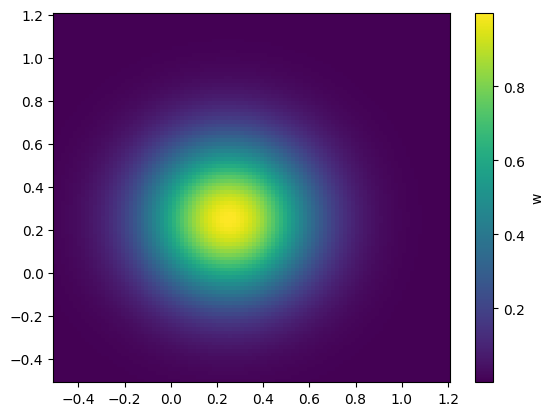

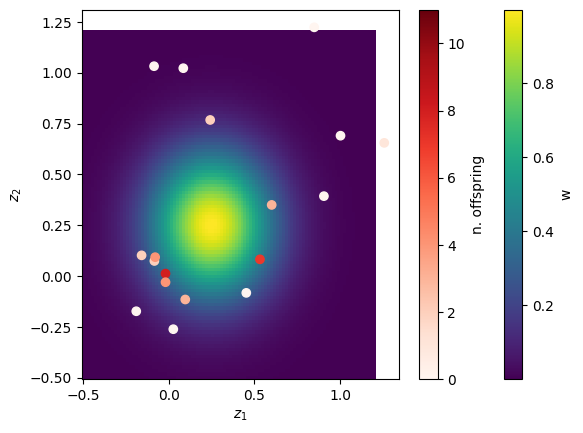

In [67]:
# Make meshgrid
X, Y = np.meshgrid(np.linspace(-0.5,1.2,100), np.linspace(-0.5,1.2,100))

# Flatten to feed into fit_gaus
z2 = np.column_stack([X.ravel(), Y.ravel()])

# Evaluate w2
w2_g = hanoi.fit_gaus(z_opt=np.array([0.25, 0.25], dtype=np.float64),
                    sigma=0.25,
                    z=z2)

# Reshape to grid for pcolormesh
w2_g_grid = w2_g.reshape(100, 100)

fig, ax = plt.subplots()

# Draw tiled background
pcm = ax.pcolormesh(X, Y, w2_g_grid, cmap='viridis', shading='auto')
plt.colorbar(pcm, ax=ax, label='w')


fig, ax = plt.subplots()

# Static scatter (background)
sc_bg = ax.pcolormesh(X, Y, w2_g_grid, cmap='viridis', shading='auto')
plt.colorbar(sc_bg, ax=ax, label='w')
# Moving scatter (foreground)
vmin = gens.n_offspring.min()
vmax = gens.n_offspring.max()
sc_fg = ax.scatter(
    gens.phenotype[0, :, 0],
    gens.phenotype[0, :, 1],
    c=gens.n_offspring[0],
    cmap="Reds",
    vmin=vmin,
    vmax=vmax
)
plt.colorbar(sc_fg, ax=ax, label='n. offspring')

ax.set_xlabel('$z_1$')
ax.set_ylabel('$z_2$')

def update(i):
    sc_fg.set_offsets(gens.phenotype[i])  # update positions
    sc_fg.set_array(gens.n_offspring[i])  # update colours
    return sc_fg,

anim = FuncAnimation(fig, update, frames = gens.n_gen-1, interval = 500, blit = True)

In [68]:
HTML(anim.to_jshtml())

Also, how distribution of breeding value changed over generations can be visualised.

In [69]:
def plot_bivariate_normal_contour(mean, cov, percentile=0.95, ax=None, **ellipse_kwargs):
    mean = np.asarray(mean)
    cov = np.asarray(cov)

    # Eigen decomposition
    eigvals, eigvecs = np.linalg.eigh(cov)
    order = eigvals.argsort()[::-1]  # descending
    eigvals, eigvecs = eigvals[order], eigvecs[:, order]

    # Rotation angle of ellipse
    angle = np.degrees(np.arctan2(eigvecs[1,0], eigvecs[0,0]))

    # Chi-square scaling for desired percentile
    s = chi2.ppf(percentile, df=2)

    # Width and height 
    width, height = 2 * np.sqrt(eigvals * s)

    if ax is None:
        fig, ax = plt.subplots()

    # Create and add ellipse
    ellipse = Ellipse(mean, width=width, height=height, angle=angle, **ellipse_kwargs)
    ax.add_patch(ellipse)
    
    return ellipse   # return the patch, not ax


In [70]:
contours = []

def update(i):
    sc_fg.set_offsets(gens.breed_val[i].mean.T)

    global contours
    # remove old ellipses
    for e in contours:
        e.remove()
    contours = []

    # add new ellipses
    for j in range(gens.breed_val[i].mean.shape[1]):
        mean = z_ref + gens.breed_val[i].mean[:, j]
        cov = c_ref + gens.breed_val[i].varcov[j]
        e = plot_bivariate_normal_contour(mean, cov, ax=ax, edgecolor='tab:orange', facecolor='none')
        contours.append(e)

    return [sc_fg] + contours


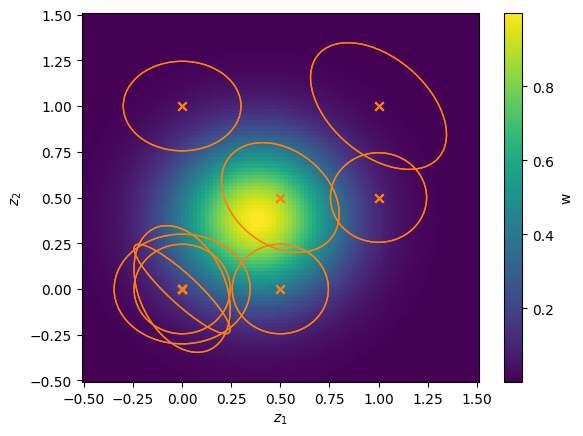

In [71]:
# Make meshgrid
X, Y = np.meshgrid(np.linspace(-0.5,1.5,100), np.linspace(-0.5,1.5,100))

fig, ax = plt.subplots()

# Flatten to feed into fit_gaus
z2 = np.column_stack([X.ravel(), Y.ravel()])

# Evaluate w2
w2_g = hanoi.fit_gaus(z_opt=np.array([0.25, 0.25], dtype=np.float64),
                    sigma=0.25,
                    z=z2)


# Draw tiled background
sc_bg = ax.pcolormesh(X, Y, w2_g_grid, cmap='viridis', shading='auto')
plt.colorbar(sc_bg, ax=ax, label='w')

# --- Moving points (foreground) ---
sc_fg = ax.scatter(
    gens.breed_val[0].mean.T[:, 0],
    gens.breed_val[0].mean.T[:, 1],
    c='tab:orange',
    marker='x'
)

ax.set_xlabel('$z_1$')
ax.set_ylabel('$z_2$')

# --- Track ellipses ---
contours = []

def update(i):
    # Update moving points
    sc_fg.set_offsets(gens.breed_val[i].mean.T)

    # Remove old ellipses
    global contours
    for e in contours:
        e.remove()
    contours = []

    # Add new ellipses
    for j in range(gens.breed_val[i].mean.shape[1]):
        mean = z_ref + gens.breed_val[i].mean[:, j]
        cov = c_ref + gens.breed_val[i].varcov[j]
        e = plot_bivariate_normal_contour(
            mean, cov,
            percentile=0.95,
            ax=ax,
            edgecolor='tab:orange',
            facecolor='none'
        )
        contours.append(e)

    return [sc_fg] + contours

# --- Animate ---
anim = FuncAnimation(fig, update, frames=gens.n_gen, interval=500, blit=False)

In [72]:
HTML(anim.to_jshtml())

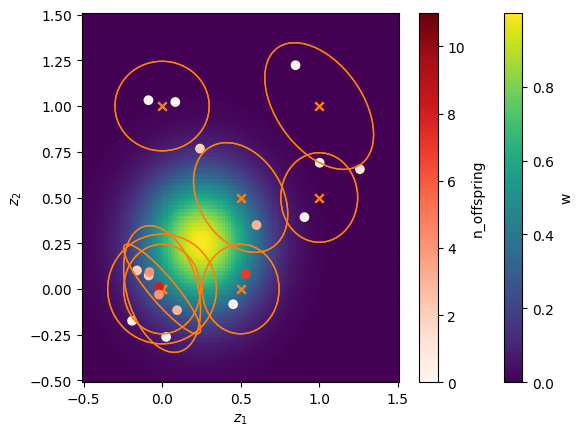

In [73]:
# Make meshgrid
X, Y = np.meshgrid(np.linspace(-0.5,1.5,100), np.linspace(-0.5,1.5,100))

fig, ax = plt.subplots()

# Flatten to feed into fit_gaus
z2 = np.column_stack([X.ravel(), Y.ravel()])

# Evaluate w2
w2_g = hanoi.fit_gaus(z_opt=np.array([0.25, 0.25], dtype=np.float64),
                    sigma=0.25,
                    z=z2)

# Reshape to grid for pcolormesh
w2_g_grid = w2_g.reshape(100, 100)

# Draw tiled background
sc_bg = ax.pcolormesh(X, Y, w2_g_grid, cmap='viridis', shading='auto')
plt.colorbar(sc_bg, ax=ax, label='w')


# --- Moving points: breeding values (orange x) ---
sc_fg_bv = ax.scatter(
    gens.breed_val[0].mean.T[:, 0],
    gens.breed_val[0].mean.T[:, 1],
    c='tab:orange',
    marker='x'
)

# --- Moving points: phenotype colored by n_offspring ---
vmin = gens.n_offspring.min()
vmax = gens.n_offspring.max()
sc_fg_pheno = ax.scatter(
    gens.phenotype[0, :, 0],
    gens.phenotype[0, :, 1],
    c=gens.n_offspring[0],
    cmap="Reds",
    vmin=vmin,
    vmax=vmax
)
plt.colorbar(sc_fg_pheno, ax=ax, label='n_offspring')

ax.set_xlabel('$z_1$')
ax.set_ylabel('$z_2$')

# --- Track ellipses ---
contours = []

def update(i):
    # Update breeding value points
    sc_fg_bv.set_offsets(gens.breed_val[i].mean.T)

    # Update phenotype points and colors
    sc_fg_pheno.set_offsets(gens.phenotype[i])
    sc_fg_pheno.set_array(gens.n_offspring[i])

    # Remove old ellipses
    global contours
    for e in contours:
        e.remove()
    contours = []

    # Add new ellipses for breeding values
    for j in range(gens.breed_val[i].mean.shape[1]):
        mean = z_ref + gens.breed_val[i].mean[:, j]
        cov = c_ref + gens.breed_val[i].varcov[j]
        e = plot_bivariate_normal_contour(
            mean, cov,
            percentile=0.95,
            ax=ax,
            edgecolor='tab:orange',
            facecolor='none'
        )
        contours.append(e)

    return [sc_fg_bv, sc_fg_pheno] + contours

# --- Animate ---
anim = FuncAnimation(fig, update, frames=gens.n_gen, interval=500, blit=False)

In [74]:
HTML(anim.to_jshtml())

In [76]:
anim.save('2025_09_01.gif', writer='pillow', fps=4)

In [103]:
z_ref

array([0., 0.])

In [104]:
M.mean

array([[1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.]])